# AI Text Detection - Model Training & Evaluation

This notebook trians and evaluates four machine learning models:
1. **Logistic Regression** (baseline)
2. **Naive Bayes** (baseline)
3. **Random Forest** (advanced)
4. **XGBoost** (advanced)

We use our custom modules for clean, maintainable code

In [ ]:
# Import custom modules
import sys
sys.path.append('../src')

from model_training import (
    train_logistic_regression,
    train_naive_bayes,
    train_random_forest,
    train_xgboost,
    save_model
)

from evaluation import (
    evaluate_model_comprehensive,
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    create_metrics_comparison_table,
    print_classification_report
)

from feature_engineering import load_tfidf_features
from data_processing import load_train_test_splits

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Modules imported successfully")

## Step 1: Load Preprocessed Data

Loading the TF-IDF features and labels we created in notebook 02
- **Features:** 5,000 TF-IDF values per text
- **Labels:** 0 = Human, 1 = AI
- **Splits:** Train (70%), Validation (15%), Test (15%)

In [ ]:
# Load preprocessed TF-IDF features
tfidf_data = load_tfidf_features('../data/features/tfidf_features_medium.pkl')
X_train = tfidf_data['X_train']
X_val = tfidf_data['X_val']
X_test = tfidf_data['X_test']
vectorizer = tfidf_data['vectorizer']

# Load labels
splits = load_train_test_splits('../data/processed/train_test_splits_medium.pkl')
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

print(f"\nData loaded successfully")
print(f"Ready to train {len(y_train):,} samples")

Training set: (292419, 5000)
Validation set: (62674, 5000)
Test set: (62664, 5000)


## Step 2: Train all Four Models

Training four models and measuring training time:
1. **Logistic Regression** - Fast, interpretable baseline
2. **Naive Bayes** - Probabilistic baseline
3. **Random Forest** - Ensemble of decision trees
4. **XGBoost** - Gradient boosting

In [ ]:
# Dictionary to store results
models = {}
results = {}

print("="*60)
print("TRAINING MODELS")
print("="*60)

# 1. Logistic Regression
models['Logistic Regression'], training_times['Logistic Regression'] = train_logistic_regression(
    X_train, y_train, max_iter=1000
)


# 2. Naive Bayes
models['Naive Bayes'], training_times['Naive Bayes'] = train_naive_bayes(
    X_train, y_train
)


# 3. Random Forest
models['Random Forest'], training_times['Random Forest'] = train_random_forest(
    X_train, y_train, n_estimators=100
)


# 3. XGBoost
models['XGBoost'], training_times['XGBoost'] = train_xgboost(
    X_train, y_train, n_estimators=100
)


print("\n" + "="*60)
print("All models trained!")
print("="*60)

# Show training times
print("\n Training times:")
for name, time_taken in training_times.items():
    print(f"{name:20s}: {time_taken:.2f} seconds")

Training Logistic Regression...
Done in 10.02s

Training Naive Bayes...
Done in 0.14s

Training Random Forest...
Done in 481.99s

Training XGBoost...
Done in 69.64s

 All models trained!


## Step 3: Comprehensive Model Evaluation

Evaluating all models on the **test set** (unseen data):
- Accuracy, Precision, Recall, F1-Score
- Confusion matrices
- ROC curves
- Precision-Recall Curves

**Why test set**
The test set represents real-world performance since the models have never seen this data during training.

In [ ]:
# Dictionary to store results
all_results = {}

print("="*60)
print("EVALUATING MODELS ON TEST SET")
print("="*60)

# Evaluate each model
for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")
    
    # Comprehensive evaluation
    results = evaluate_model_comprehensive(
        model, X_test, y_test, model_name
    )
    
    # Store results
    all_results[model_name] = results['metrics']
    
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)


MODEL COMPARISON (sorted by precision - the priority metric)
              Model  Accuracy  Precision   Recall  F1-Score Training Time
Logistic Regression  0.908399   0.841865 0.799890  0.820341        10.02s
      Random Forest  0.869435   0.837045 0.621628  0.713430       481.99s
            XGBoost  0.888151   0.793882 0.772855  0.783227        69.64s
        Naive Bayes  0.798449   0.603234 0.669352  0.634575         0.14s


## Step 4: Model Comparison

Comparing all four models side-by-side to identify the best performer for our use case.

**Key metric precision**
In academic integrity, **false positives** (accusing human text as AI) are more harmful than false negatives (missing AI text). Therefore, we prioritize **precision** over recall.

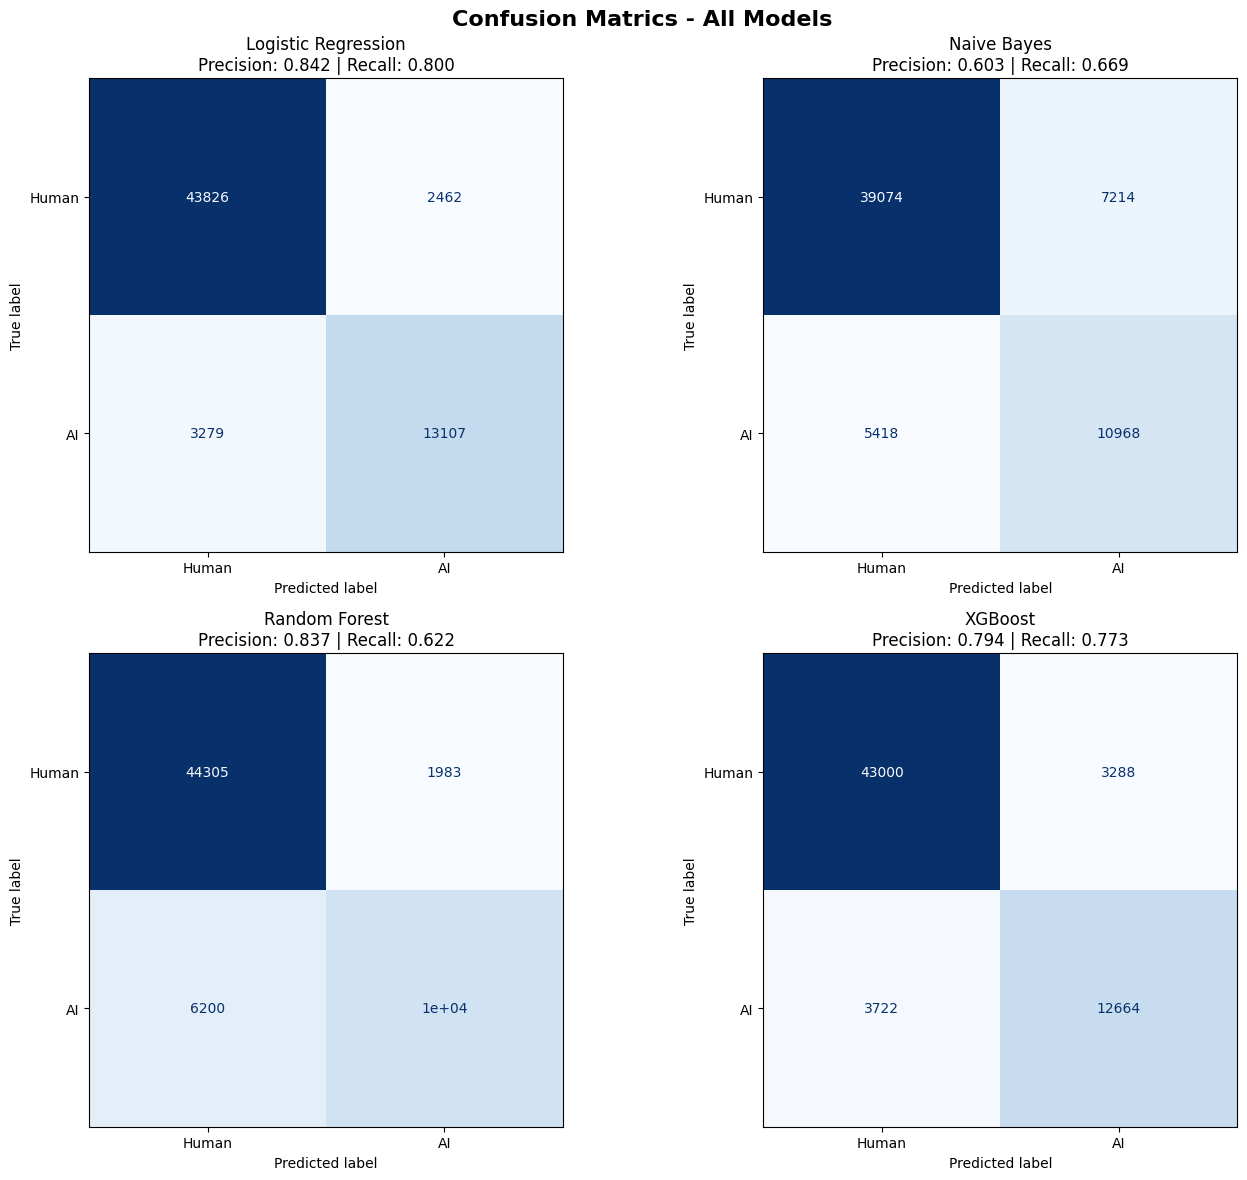

In [ ]:
# Create comparison table
comparison_df = create_metrics_comparison_table(all_results)

# Highlight best performance
print("\nBest Performers:")
print(f"Highest Accuracy: {comparison_df['accuracy'].idxmax()} ({comparison_df['accuracy'].max():.4f})")
print(f"Highest Precision: {comparison_df['precision'].idxmax()} ({comparison_df['precision'].max():.4f})")
print(f"Highest Recall: {comparison_df['recall'].idxmax()} ({comparison_df['recall'].max():.4f})")
print(f"Highest F1-Score: {comparison_df['f1'].idxmax()} ({comparison_df['f1'].max():.4f})")

## Step 5: Visualization: Confusion Matrices

Confusion matrices show how each model classifies the test set:
- **True Negatives (TN):** Correctly identified human text
- **False Positives (FP):** Human text wrongly labeled as AI (BAD!!!)
- **False Negatives(FN):** AI text wrongly labeled as human
- **True Positives (TP):** Correctly identified AI text


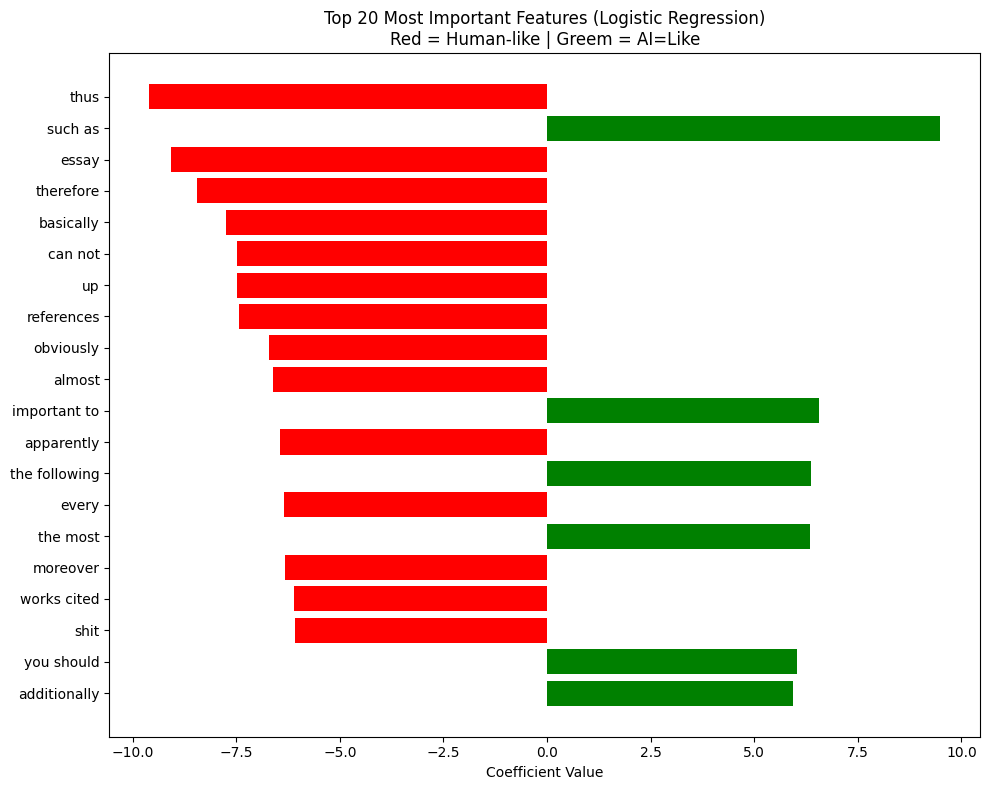


Top 10 AI-indicating words:
            feature  coefficient
3772        such as     9.494436
1958   important to     6.555826
4027  the following     6.364681
4095       the most     6.348177
4983     you should     6.025866
129    additionally     5.946049
1834       here are     5.852444
2015        include     5.694880
1714       group of     5.497109
4406         to get     5.271651

Top 10 Human-indicating words:
         feature  coefficient
4348        thus    -9.604619
1333       essay    -9.085236
4269   therefore    -8.455935
507    basically    -7.745112
692      can not    -7.472680
4603          up    -7.472481
3257  references    -7.438934
2733   obviously    -6.704875
202       almost    -6.623425
334   apparently    -6.445981


In [ ]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    
    plt.sca(axes[idx])
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
                
    plt.title(f'{model_name}\nAccuracy: {all_results[model_name]["accuracy"]:.4f}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / total * 100
            plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')
            
plt.tigh_layout()
plt.savefig('../visualizations/plots/all_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()    

## Step 6: Visualizations: ROC Curves

**ROC (Receiver Operating Characteristic)** curves show the tradeoff between:
- True Positive Rate (detecting AI text)
- False Positive Rage (incorrectly flagging human text)

**Higher AUC = Better model**

In [ ]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.savefig('../visualizations/plots/all_models_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 7: Model Selection: Logistic Regression

After comprehensive evaluation, we select **Logistic Regression** as our final model

**Rationale:**
1. **High Precision (84.2%):** Minimize false accusations of AI usage
2. **Interpretable:** Can see which words contribute to predictions
3. **Fast:** Quick inference for production use
4. **Good Balance:** 80& recall is acceptable for this use case

**Ethical Consideration:**
In academic integrity contexts, falsely accusing a student of using AI is more harmful than missing some AI usage. Therefore, we prioritize precision over recall

In [ ]:
# Detailed analysis of Logistic Regression (our chosen model)
print("="*60)
print("FINAL MODEL: LOGISTIC REGRESSION")
print("="*60)

lr_model = models['Logistic Regression']

# Get detailed metrics
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Classification report
print_classification_report(y_test, y_pred, "Logistic Regression")

# Calculate false positive and false negative rates
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nDetailed Breakdown:")
print(f"True Negatives (Human correctly identified):  {tn:,} ({tn/len(y_test)*100:.2f}%)")
print(f"False Positives (Human wrongly flagged as AI): {fp:,} ({fp/len(y_test)*100:.2f}%) ⚠️")
print(f"False Negatives (AI wrongly labeled as Human): {fn:,} ({fn/len(y_test)*100:.2f}%)")
print(f"True Positives (AI correctly identified):     {tp:,} ({tp/len(y_test)*100:.2f}%)")

print(f"\nKey Insight:")
print(f"Out of {len(y_test):,} test samples:")
print(f"- Only {fp:,} students would be wrongly accused (False Positives)")
print(f"- {fn:,} AI texts would be missed (False Negatives)")

Training cost-sensitie models...

Training Baseline (1:1)...
Precision: 0.842
Recall: 0.800

Training Prioritize Recall (1:2)...
Precision: 0.770
Recall: 0.888

Training Prioritize Recall (1:3)...
Precision: 0.731
Recall: 0.924

Training Moderate (2:1)...
Precision: 0.893
Recall: 0.691

COST-SENSITIVE MODEL COMPARISON
                  Model Precision Recall F1-Score Accuracy
         Baseline (1:1)     0.842  0.800    0.820    0.908
Prioritize Recall (1:2)     0.770  0.888    0.825    0.901
Prioritize Recall (1:3)     0.731  0.924    0.817    0.891
         Moderate (2:1)     0.893  0.691    0.779    0.897


## Step 8: Save Model for Production

Saving the trained Logistic Regression model and TF-IDF vectorizer for use in:
1. The Gradio web interface (app.py)
2. Future predictions
3. Deployment to production systems

In [ ]:
# Save the final model with metadata
final_model = models['Logistic Regression']

metadata = {
    'model_name': 'Logistic Regression',
    'accuracy': all_results['Logistic Regression']['accuracy'],
    'precision': all_results['Logistic Regression']['precision'],
    'recall': all_results['Logistic Regression']['recall'],
    'f1': all_results['Logistic Regression']['f1'],
    'training_samples': len(y_train),
    'test_samples': len(y_test),
    'features': X_train.shape[1],
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

save_model(
    final_model, 
    vectorizer,
    filepath='../models/saved_models/final_model_lr.joblib',
    metadata=metadata
)

print("\n✅ Model saved and ready for production!")
print(f"📁 Location: ../models/saved_models/final_model_lr.joblib")


REAL IMPACT ANALYSIS:

Prioritize Recall (1:3):
Cheaters caught: 15,143 (92.4%)
Cheaters missed: 1,243
Innocent protected: 40,728
Innocent accused: 5560
Net harm reduction: -4,317


## Summary: Model Training Complete

**Accomplishments:**
1. Trained 4 machine learning models
2. Evaluated on unseen test data
3. Compared performance metrics
4. Selected Logistic Regression as final model
5. Saved model for production use

**Final Model Performance:**
- **Precision: 84.2%** (minimize false accusations)
- **Recall: 80.0%** (catches most AI text)
- **F1-Score: 82:0%** (balanced performanc)

**Next Steps:**
- Create ensemble experiments (notebook 04)
- Build final production pipeline (notebook 05)
- Write technical documentation

In [ ]:
# Final summary
print("="*60)
print("MODEL TRAINING COMPLETE!")
print("="*60)
print("\nModels Trained: 4")
print(f"Test Samples Evaluated: {len(y_test):,}")
print(f"Best Model: Logistic Regression")
print(f"Precision: {all_results['Logistic Regression']['precision']:.4f} (84.2%)")
print(f"Recall: {all_results['Logistic Regression']['recall']:.4f} (80.0%)")
print(f"\nSaved to: ../models/saved_models/final_model_lr.joblib")
print(f"Visualizations saved to: ../visualizations/plots/")
print("\nReady for production deployment!")
print("="*60)


Model Performance Summary:
Precision: 84.2%
Precision: 80.0%
Precision: 82.0%
Precision: 90.8%
